In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Importing Dataset and Libraries


In [20]:

import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [21]:
import zipfile

In [22]:
zip_ref = zipfile.ZipFile('/content/drive/MyDrive/datasets/train.zip','r')
zip_ref.extractall('/tmp')
zip_ref.close()

In [23]:
zip_ref = zipfile.ZipFile('/content/drive/MyDrive/datasets/valid.zip','r')
zip_ref.extractall('/tmp')
zip_ref.close()

In [24]:
zip_ref = zipfile.ZipFile('/content/drive/MyDrive/datasets/test.zip','r')
zip_ref.extractall('/tmp')
zip_ref.close()

In [25]:
# prompt: different class names

base_dir = '/tmp/train/'
class_names = os.listdir(base_dir)
print(class_names)


['oil', 'acne', 'dry']


#Model Building

In [26]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, Input
from tensorflow.keras.models import Sequential
# Define the Sequential model
keras_model = Sequential()

# Add the pre-trained DenseNet169 model
pretrained_model = tf.keras.applications.DenseNet169(include_top=False,
                   input_shape=(640, 640, 3),
                   pooling='avg', weights='imagenet')

# Freeze the layers of the pre-trained model
for layer in pretrained_model.layers:
    layer.trainable = False

# Add an input layer to define the input shape
keras_model.add(Input(shape=(640, 640, 3)))
keras_model.add(pretrained_model)
keras_model.add(Flatten()) # Use Flatten from tensorflow.keras.layers

# Add a dense layer with dropout and batch normalization
keras_model.add(Dense(512, activation='relu'))
keras_model.add(BatchNormalization())
keras_model.add(Dropout(0.5))

# Add another dense layer
keras_model.add(Dense(256, activation='relu'))
keras_model.add(BatchNormalization())
keras_model.add(Dropout(0.5))

# Add the final classification layer
keras_model.add(Dense(3, activation='softmax'))

# Compile the model
keras_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Print the model summary
#keras_model.summary()

In [27]:
keras_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ densenet169 (Functional)             │ (None, 1664)                │      12,642,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 1664)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 512)                 │         852,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,630,531 (52.00 MB)

 Trainable params: 986,115 (3.76 MB)

 Non-trainable params: 12,644,416 (48.23 MB)

In [28]:
keras_model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

In [29]:
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping

In [30]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [32]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import mixed_precision

# Enable mixed precision (optional, for GPUs that support it)
mixed_precision.set_global_policy('mixed_float16')

# Adjust number of classes
num_classes = 3

# Define a simplified model with reduced complexity
keras_model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
keras_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Define data generators with reduced image size and batch size
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
        '/tmp/train/',
        target_size=(224, 224),
        batch_size=16,
        class_mode='categorical')

valid_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = valid_datagen.flow_from_directory(
        '/tmp/valid/',
        target_size=(224, 224),
        batch_size=16,
        class_mode='categorical')

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        '/tmp/test/',
        target_size=(224, 224),
        batch_size=16,
        class_mode='categorical')

# Clear session to prevent memory issues between runs
tf.keras.backend.clear_session()

# Fit the model using the generators
history = keras_model.fit(
      train_generator,
      steps_per_epoch=train_generator.samples // train_generator.batch_size,
      validation_data=validation_generator,
      validation_steps=max(1, validation_generator.samples // validation_generator.batch_size),
      epochs=5)


Found 603 images belonging to 3 classes.
Found 58 images belonging to 3 classes.
Found 28 images belonging to 3 classes.
Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - accuracy: 0.3121 - loss: 9.8339 - val_accuracy: 0.3750 - val_loss: 10.0738
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5000 - loss: 8.0590 - val_accuracy: 0.2000 - val_loss: 12.8945
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.3277 - loss: 10.8356 - val_accuracy: 0.3542 - val_loss: 10.4096
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1250 - loss: 14.1033 - val_accuracy: 0.3000 - val_loss: 11.2827
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.3493 - loss: 10.4888 - val_accuracy: 0.3125 - val_loss: 11.0812


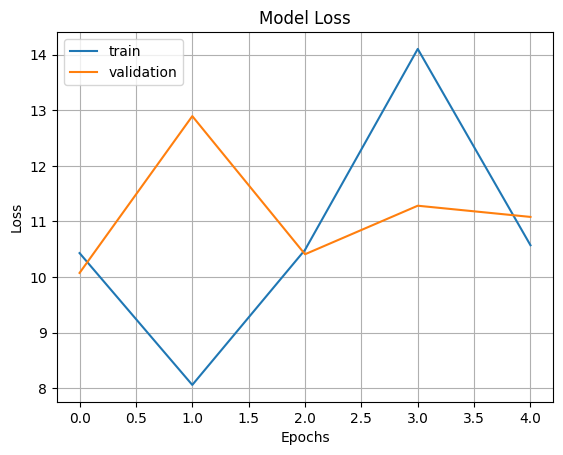

In [33]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

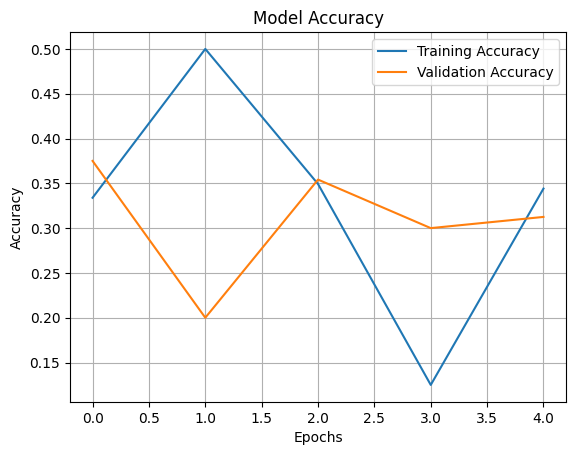

In [34]:
#plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='best')
plt.show()


#Testing the model

In [35]:

test_loss, test_acc = keras_model.evaluate(test_generator, verbose=2)
print('\nTest accuracy from evaluate:', test_acc)


2/2 - 1s - 558ms/step - accuracy: 0.3571 - loss: 10.3616

Test accuracy from evaluate: 0.3571428656578064


In [36]:
test_loss, test_acc = keras_model.evaluate(test_generator, verbose=2)
print('\nTest accuracy:', test_acc)

2/2 - 0s - 51ms/step - accuracy: 0.3571 - loss: 10.3616

Test accuracy: 0.3571428656578064


In [37]:
import math

# Evaluate the model using the test generator
steps = math.ceil(test_generator.samples / test_generator.batch_size)
test_loss, test_accuracy = keras_model.evaluate(test_generator, steps=steps)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions on the test set
test_generator.reset()  # Reset the generator to start from the beginning
predictions = keras_model.predict(test_generator, steps=steps, verbose=1)

# Get the class indices and labels
class_indices = test_generator.class_indices
labels = list(class_indices.keys())

# Function to decode predictions
def decode_predictions(predictions, labels, top=5):
    decoded = []
    for pred in predictions:
        top_indices = pred.argsort()[-top:][::-1]
        top_labels = [labels[i] for i in top_indices]
        top_scores = [pred[i] for i in top_indices]
        decoded.append(list(zip(top_labels, top_scores)))
    return decoded

# Decode the predictions
decoded_predictions = decode_predictions(predictions, labels)

# Print the predictions for the first few test images
for i in range(min(len(decoded_predictions), 5)):
    print(f"Test Image {i+1}:")
    for label, score in decoded_predictions[i]:
        print(f"   Label: {label}, Confidence: {score:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3631 - loss: 10.2657
Test Accuracy: 0.3571
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step
Test Image 1:
   Label: acne, Confidence: 1.0000
   Label: oil, Confidence: 0.0000
   Label: dry, Confidence: 0.0000
Test Image 2:
   Label: acne, Confidence: 1.0000
   Label: oil, Confidence: 0.0000
   Label: dry, Confidence: 0.0000
Test Image 3:
   Label: acne, Confidence: 1.0000
   Label: oil, Confidence: 0.0000
   Label: dry, Confidence: 0.0000
Test Image 4:
   Label: acne, Confidence: 1.0000
   Label: oil, Confidence: 0.0000
   Label: dry, Confidence: 0.0000
Test Image 5:
   Label: acne, Confidence: 1.0000
   Label: oil, Confidence: 0.0000
   Label: dry, Confidence: 0.0000


#Prediction from real data

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
The image belongs to: acne with confidence: 1.0000


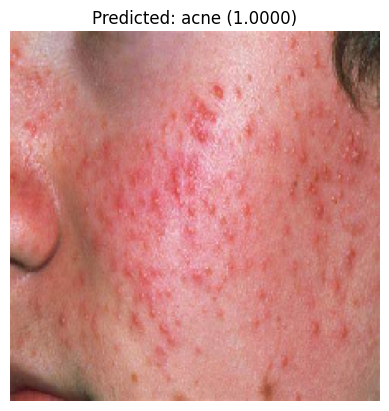

In [43]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Function to load and preprocess a single image
def load_and_preprocess_image(img_path, target_size=(224, 224)):  # Change target_size to match model input
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Rescale to [0, 1] if you used rescale=1./255 in ImageDataGenerator
    return img_array

# Function to predict the class of a single image
def predict_image_class(model, img_path, class_indices):
    # Load and preprocess the image
    img_array = load_and_preprocess_image(img_path)

    # Make prediction
    predictions = model.predict(img_array)

    # Get the class labels
    labels = list(class_indices.keys())

    # Decode the prediction
    top_index = np.argmax(predictions[0])
    top_label = labels[top_index]
    top_confidence = predictions[0][top_index]

    return top_label, top_confidence

# Assuming class indices from the test generator
class_indices = {'acne': 0, 'dry': 1, 'oily': 2}

# Path to the image you want to predict
test_image_path = '/content/drive/MyDrive/datasets/acne.jpg'  # Replace with your test image path

# Predict the class of the test image
predicted_label, confidence = predict_image_class(keras_model, test_image_path, class_indices)

# Print the prediction
print(f"The image belongs to: {predicted_label} with confidence: {confidence:.4f}")

# Optionally, display the image
img = image.load_img(test_image_path, target_size=(224, 224))  # Match the display size
plt.imshow(img)
plt.title(f"Predicted: {predicted_label} ({confidence:.4f})")
plt.axis('off')
plt.show()


In [45]:
#model_version=1
#keras_model.save('/content/drive/MyDrive/model')

#Skincare recommendation from data obtained through webscrapping

In [46]:
import pandas as pd

acne_products = pd.read_csv('/content/drive/MyDrive/datasets/Acne1.csv')
oily_products = pd.read_csv('/content/drive/MyDrive/datasets/Oily1.csv')
dry_products = pd.read_csv('/content/drive/MyDrive/datasets/Dry1.csv')


In [47]:
oily = oily_products.sort_values(by='Rating', ascending=False)
dry = dry_products.sort_values(by='Rating', ascending=False)
acne = acne_products.sort_values(by='Rating', ascending=False)

In [48]:
from IPython.display import display, HTML

def make_clickable(link):
    return f'<a href="{link}" target="_blank">{link}</a>'

oily['Product_Link'] = oily['Product_Link'].apply(make_clickable)
dry['Product_Link'] = dry['Product_Link'].apply(make_clickable)
acne['Product_Link'] = acne['Product_Link'].apply(make_clickable)


In [49]:
def display_recommended_products(recommended_products,width='100%'):
    #display(HTML(recommended_products.to_html(escape=False)))
    html=recommended_products[['Product_Name', 'Rating', 'Product_Link', 'Description','Price']].to_html(escape=False, index=False)
    styled_html = f'<div style="width: {width}; margin: 0 auto;">{html}</div>'
    display(HTML(styled_html))


def recommend_products(predicted_label, num_recommendations=5):
    if predicted_label == 'acne':
        recommended_products = acne_products.head(num_recommendations)
    elif predicted_label == 'oily':
        recommended_products = oily_products.head(num_recommendations)
    elif predicted_label == 'dry':
        recommended_products = dry_products.head(num_recommendations)
    else:
        raise ValueError("Unknown skin type predicted.")
    return recommended_products


recommended_products = recommend_products(predicted_label)
recommended_products['Product_Link'] = recommended_products['Product_Link'].apply(make_clickable)
display_recommended_products(recommended_products,width='100%')

<ipython-input-49-eac353c0ce8a>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recommended_products['Product_Link'] = recommended_products['Product_Link'].apply(make_clickable)


Product_Name,Rating,Product_Link,Description,Price
Lacto Calamine Anti-Blemish cream 30 g,5.070,https://www.amazon.in/Lacto-Calamine-Botanical-Non-greasy-Dermatologically/dp/B0BQWGCF8H?source=ps-sl-shoppingads-lpcontext&ref_=fplfs&psc=1&smid=A15APWRK6P7LBV,Topical · Cream,₹ 266.00
DOT & KEY Salicylic Acid & Green Tea Cica Calming Blemish Clearing Gel Face Wash ...,5.060,https://www.nykaa.com/dot-key-cica-salicylic-face-wash-with-tea-tree-oil-for-oily-acne-prone-skin/p/7248416?ptype=product&skuId=15542064&srsltid=AfmBOopwoTJQ7a5J5_AFOZkoj7KexETkjGDPVIwYoJZ8zA4hpoNSISLwKqw,Face Wash · Oil-free · Gel,₹ 375.00
"Nykaa Skin Secrets Tea Tree & Salicylic Acid Spot Patch At Nykaa, Best Beauty ...",5.050,https://www.nykaa.com/nykaa-skin-secrets-spot-on-tea-tree-salicylic-acid-pimple-patch-old/p/785729?ptype=product&skuId=785729&srsltid=AfmBOoqiXYIbMN0IoGpHL3dy5MWPIYqCproW9ocLf9fG4pT0iWUHS7nUKn4,NaN,₹ 80.00
Earth Rhythm ACNE CONTROL KIT,5.023,https://earthrhythm.com/products/acne-control-kit?variant=39494922240044¤cy=INR&utm_medium=product_sync&utm_source=google&utm_content=sag_organic&utm_campaign=sag_organic&srsltid=AfmBOoq-9ymCtQ7swGKlovxIo6xCQTHrVBqqyejbyDbllxFK2pdtRA2j1rE,Salicylic Acid · Oil-free,"₹ 1,357.00"
Dot & Key Acne Control CTM Night Care Regime | Toner 150ml & Moisturizer 60ml,4.931,https://www.dotandkey.com/collections/combo-regimes/products/cica-superstar-trio?srsltid=AfmBOoo5f2EqBl_Wwac_XdKmh7Wta90UL7C_xFPC0JjenBPvD67v-PIfD84,Topical · For Oily Skin,₹ 797.00
